In [40]:
import torch
from torch import nn
from sklearn.model_selection import train_test_split as tts
from sklearn.datasets import make_blobs
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score

In [5]:
x_blob,y_blob=make_blobs(n_samples=1000,n_features=2,centers=4,cluster_std=1.5,random_state=18)
df=pd.DataFrame({"x1":x_blob[:,0],"x2":x_blob[:,1],"label":y_blob})
df

,x1,x2,label
0,6.051858,-6.461126,1
1,5.145839,9.377967,3
2,3.408832,10.551062,3
3,0.602797,-0.592560,0
4,7.416456,-7.068063,1
...,...,...,...
995,1.372029,8.754836,3
996,9.287399,-8.415762,1
997,2.229628,1.802014,0
998,2.431672,5.986911,3


<Axes: xlabel='x1', ylabel='x2'>

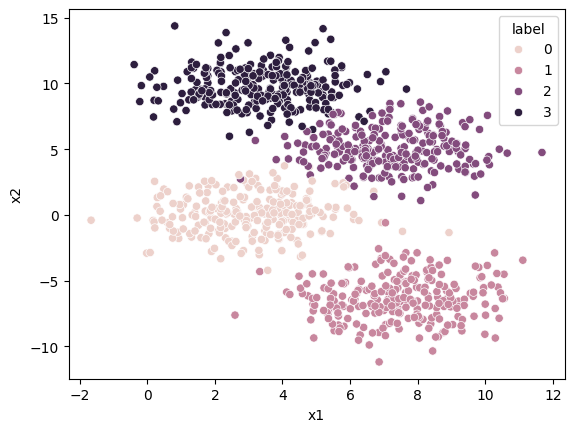

In [7]:
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label'])

In [14]:
x_blob=torch.from_numpy(x_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.float)

In [35]:
x_train,x_test,y_train,y_test=tts(x_blob,y_blob,test_size=0.2,random_state=18)
y_train=y_train.long()
y_test=y_test.long()

In [36]:
class multiclass_classifier(nn.Module):
    def __init__(self,input_features,output_features,hidden_units):
        super().__init__()

        self.layerstack=nn.Sequential(
            nn.Linear(in_features=input_features,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_features),
        )

    def forward(self,x):
        return self.layerstack(x)

In [37]:
model=multiclass_classifier(2,4,8)
model

multiclass_classifier(
  (layerstack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [38]:
loss_func=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)

In [39]:
epochs=10000
for _ in range(epochs):
    y_logit=model(x_train).squeeze()
    y_pred=torch.softmax(y_logit,dim=1).argmax(dim=1)
    loss=loss_func(y_logit,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [42]:
model.eval()
with torch.inference_mode():
    y_test_logit=model(x_test).squeeze()
    y_test_pred=torch.softmax(y_test_logit,dim=1).argmax(dim=1)

In [44]:
accuracy_score(y_test,y_test_pred)

0.97

In [48]:
from matplotlib import pyplot as plt
from helper_functions import plot_decision_boundary

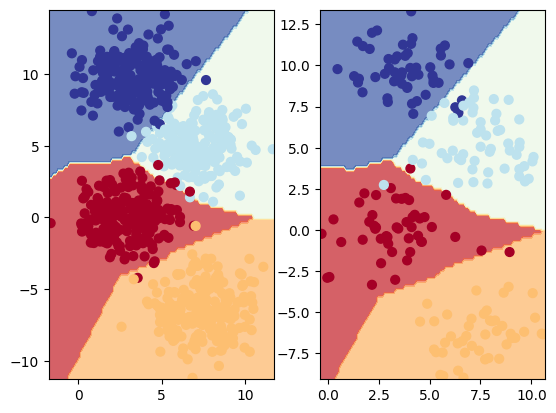

In [49]:
plt.subplot(1,2,1)
plot_decision_boundary(model,x_train,y_train)
plt.subplot(1,2,2)
plot_decision_boundary(model,x_test,y_test)